In [1]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Science
import numpy as np
import pandas as pd

# Multi-dimensional arrays and datasets
import xarray as xr

# Geospatial data analysis
import geopandas as gpd

# Geospatial operations
import rasterio


# Feature Engineering
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Machine Learning
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,classification_report,ConfusionMatrixDisplay

# Others
import os
from tqdm import tqdm

In [2]:
# Load the training data from csv file and display the first few rows to inspect the data
ground_df = pd.read_csv("../data/Training_Data.csv")
ground_df.head()

,ID,Latitude,Longitude,Occurrence Status
0,ID_TR_957A5A,-34.027900,150.771000,1
1,ID_TR_55E0AF,-34.821595,147.193697,1
2,ID_TR_7AC931,-36.617759,146.882941,0
3,ID_TR_7D3CE4,-37.470900,144.744000,1
4,ID_TR_02F669,-38.400153,145.018560,1


Here 1 indicate the frog presence and 0 indicate the non-presence of the frog at the given location.

In [3]:
#Check dataframe shape.
ground_df.shape

(6312, 4)

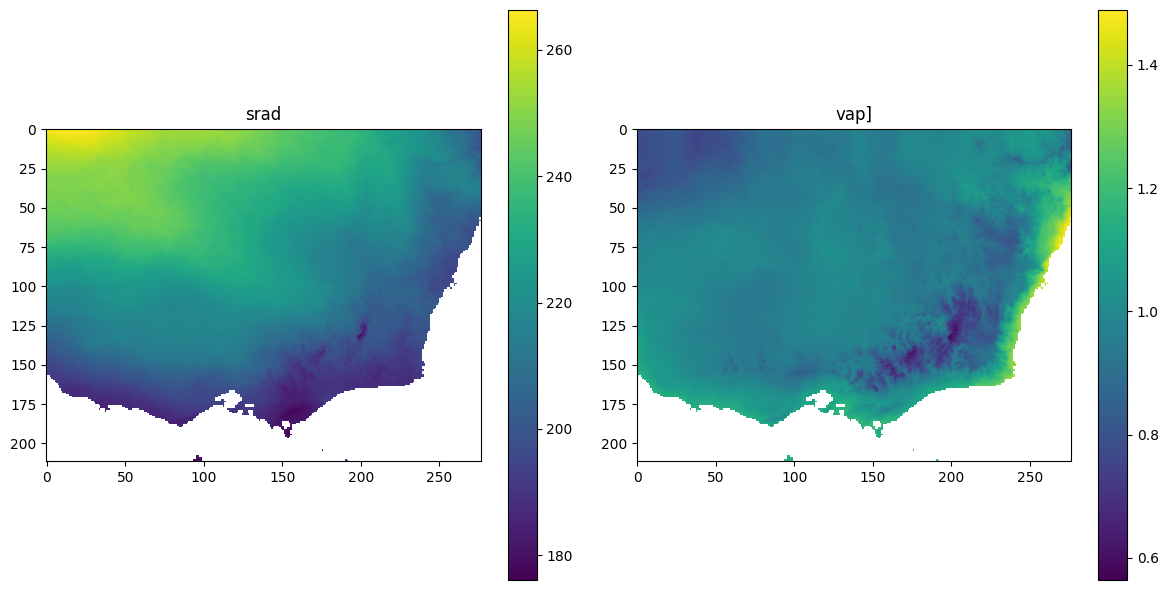

In [4]:
# Reads and plots two climatic parameters srad and vap from the GeoTIFF file.

# Open the GeoTIFF file
tiff_path = "TerraClimate_output.tiff"

# Read the variables from the GeoTIFF file
with rasterio.open(tiff_path) as src1:
    variable1 = src1.read(1)  # variable [srad]
    variable2 = src1.read(2)  # variable [vap]

# Plot the variables in a 2x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Flatten the axes for easier indexing
axes = axes.flatten()

# Plot the first parameter (srad)
im1 = axes[0].imshow(variable1, cmap='viridis')
axes[0].set_title('srad')
fig.colorbar(im1, ax=axes[0])
# axes[0].scatter(*list(zip(*indices))[::-1], s=2, c=df["Occurrence Status"].values)

# Plot the second parameter (vap)
im2 = axes[1].imshow(variable2, cmap='viridis')
axes[1].set_title('vap]')
fig.colorbar(im2, ax=axes[1])
# axes[1].scatter(*list(zip(*indices))[::-1], s=2, c=["b" if i == 1 else "r" for i in df["Occurrence Status"].values])

plt.tight_layout()
plt.show()


In [5]:
df = pd.read_csv("../data/Training_Data.csv")
df["Occurrence Status"].values

array([1, 1, 0, ..., 1, 1, 0], shape=(6312,))

### Extracting Climatic variables from the TerraClimate sample GeoTiff image

In [6]:
# Extracts satellite variables from a GeoTIFF based on coordinates from a csv file and returns them in a DataFrame.

def map_satellite_data(tiff_path, csv_path):

    df = pd.read_csv(csv_path)

    # Open the GeoTIFF file and load data into xarray DataArrays
    with rasterio.open(tiff_path) as dataset:
        # Read raster variables into numpy arrays
        srad_data = dataset.read(1)  # variable 1 (e.g., srad)
        vap_data = dataset.read(2)   # variable 2 (e.g., vap)

        # Generate coordinate grids (lon/lat) from raster bounds and resolution
        lon = np.linspace(dataset.bounds.left, dataset.bounds.right, dataset.width)
        lat = np.linspace(dataset.bounds.top, dataset.bounds.bottom, dataset.height)

        # Create xarray DataArrays for each variable
        srad_da = xr.DataArray(
            srad_data, coords=[("lat", lat), ("lon", lon)], dims=["lat", "lon"]
        )
        vap_da = xr.DataArray(
            vap_data, coords=[("lat", lat), ("lon", lon)], dims=["lat", "lon"]
        )

    # Initialize lists to store extracted values
    srad_values = []
    vap_values = []

    # Extract values for each row in the DataFrame
    for _, row in tqdm(df.iterrows(), total=df.shape[0], desc="Extracting raster values"):
        target_lat, target_lon = row["Latitude"], row["Longitude"]

        try:
            # Extract the nearest values from the DataArrays
            srad_value = srad_da.sel(lat=target_lat, lon=target_lon, method="nearest").values
            vap_value = vap_da.sel(lat=target_lat, lon=target_lon, method="nearest").values
        except KeyError:
            # Handle cases where coordinates are outside raster bounds
            srad_value, vap_value = np.nan, np.nan

        srad_values.append(srad_value)
        vap_values.append(vap_value)

    # Create a DataFrame to store the variable values
    df1 = pd.DataFrame()
    df1["srad"] = srad_values
    df1["vap"] = vap_values

    return df1


In [7]:
# Mapping satellite data with training data.
final_data = map_satellite_data('TerraClimate_output.tiff', '../data/Training_Data.csv')

Extracting raster values:   0%|          | 0/6312 [00:00<?, ?it/s]

Extracting raster values: 100%|██████████| 6312/6312 [00:06<00:00, 1029.20it/s]


In [8]:
#Display first 5 rows.
final_data.head(5)

,srad,vap
0,200.7991485595703,1.2330000400543213
1,218.40399169921875,0.9420000314712524
2,204.00003051757812,0.9420000314712524
3,204.400146484375,0.9510000348091125
4,189.20396423339844,1.096000075340271


## Joining the predictor variables and response variables

In [9]:
# Combine two datasets vertically (along columns) using pandas concat function.
def combine_two_datasets(dataset1,dataset2):
    '''
    Returns a  vertically concatenated dataset.
    Attributes:
    dataset1 - Dataset 1 to be combined
    dataset2 - Dataset 2 to be combined
    '''

    data = pd.concat([dataset1,dataset2], axis=1)
    return data

In [10]:
# Combining ground data and final data into a single dataset.
final_data = combine_two_datasets(ground_df,final_data)
final_data.head()

,ID,Latitude,Longitude,Occurrence Status,srad,vap
0,ID_TR_957A5A,-34.027900,150.771000,1,200.7991485595703,1.2330000400543213
1,ID_TR_55E0AF,-34.821595,147.193697,1,218.40399169921875,0.9420000314712524
2,ID_TR_7AC931,-36.617759,146.882941,0,204.00003051757812,0.9420000314712524
3,ID_TR_7D3CE4,-37.470900,144.744000,1,204.400146484375,0.9510000348091125
4,ID_TR_02F669,-38.400153,145.018560,1,189.20396423339844,1.096000075340271


## Removing duplicates

In [11]:
# Remove duplicate rows from the DataFrame based on specified columns and keep the first occurrence
columns_to_check = ['srad', 'vap', 'Occurrence Status']
for col in columns_to_check:
    # Check if the value is a numpy array and has more than one dimension
    final_data[col] = final_data[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.ndim == 0 else x)

# Now remove duplicates
final_data = final_data.drop_duplicates(subset=columns_to_check, keep='first')
final_data.shape


(5253, 6)

In [12]:
# Resetting the index of the dataset
final_data=final_data.reset_index(drop=True)

In [13]:
final_data.head()

,ID,Latitude,Longitude,Occurrence Status,srad,vap
0,ID_TR_957A5A,-34.027900,150.771000,1,200.799149,1.233
1,ID_TR_55E0AF,-34.821595,147.193697,1,218.403992,0.942
2,ID_TR_7AC931,-36.617759,146.882941,0,204.000031,0.942
3,ID_TR_7D3CE4,-37.470900,144.744000,1,204.400146,0.951
4,ID_TR_02F669,-38.400153,145.018560,1,189.203964,1.096


In [14]:
final_data.shape

(5253, 6)

## Plotting locations on map

In [15]:
def get_point_indices(tiff_path, csv_path):
    df = pd.read_csv(csv_path)
    indices = []
    with rasterio.open(tiff_path) as dataset:
        for _, row in df.iterrows():
            lat, lon = row['Latitude'], row['Longitude']
            point = dataset.index(x=lon, y=lat)
            indices.append(point)

    return indices


indices = get_point_indices('TerraClimate_output.tiff', '../data/Training_Data.csv')

## Plotting with markings

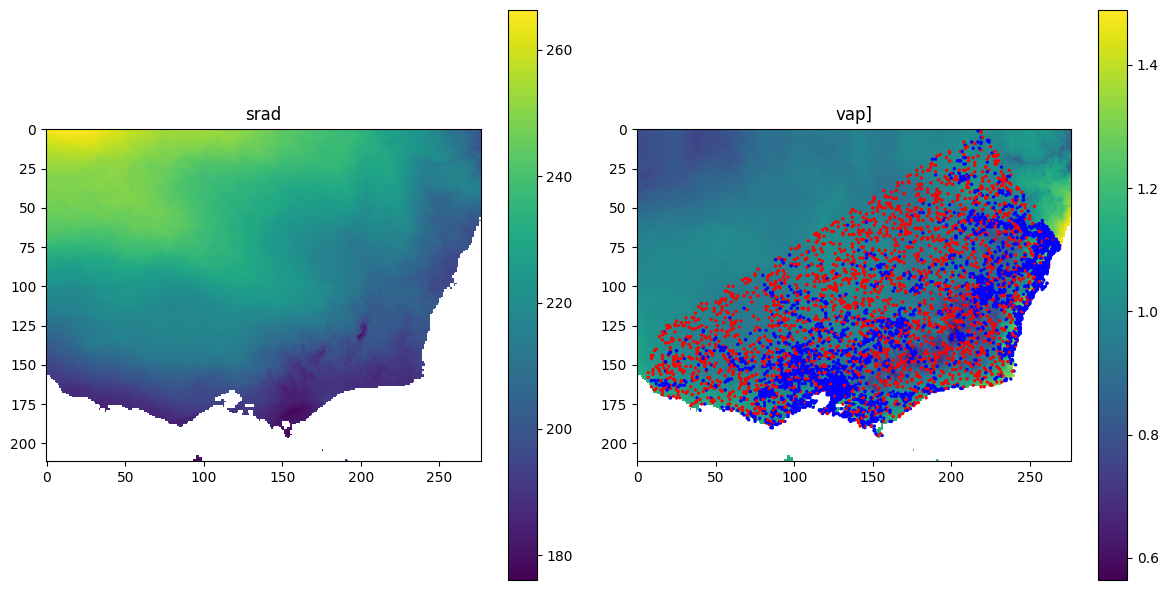

In [16]:
# Open the GeoTIFF file
tiff_path = "TerraClimate_output.tiff"

# Read the variables from the GeoTIFF file
with rasterio.open(tiff_path) as src1:
    variable1 = src1.read(1)  # variable [srad]
    variable2 = src1.read(2)  # variable [vap]

# Plot the variables in a 2x2 grid
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Flatten the axes for easier indexing
axes = axes.flatten()

# Plot the first parameter (srad)
im1 = axes[0].imshow(variable1, cmap='viridis')
axes[0].set_title('srad')
fig.colorbar(im1, ax=axes[0])
# axes[0].scatter(*list(zip(*indices))[::-1], s=2, c=df["Occurrence Status"].values)

# Plot the second parameter (vap)
im2 = axes[1].imshow(variable2, cmap='viridis')
axes[1].set_title('vap]')
fig.colorbar(im2, ax=axes[1])
axes[1].scatter(*list(zip(*indices))[::-1], s=2, c=["b" if i == 1 else "r" for i in df["Occurrence Status"].values])

plt.tight_layout()
plt.show()

<p align="justify"> Now let us select the columns required for our model building exercise. We will consider only srad and vap from the final data as our predictor variables. It does not make sense to use latitude and longitude as predictor variables, as they do not have any direct impact on predicting the presence of frog.</p>

In [17]:
# Retaining only the columns for srad, vap and Occurrence Status in the dataset.
final_data=final_data[['srad','vap','Occurrence Status']]

In [18]:
final_data.head()

,srad,vap,Occurrence Status
0,200.799149,1.233,1
1,218.403992,0.942,1
2,204.000031,0.942,0
3,204.400146,0.951,1
4,189.203964,1.096,1


In [19]:
#Create a copy of data.
model_data = final_data.copy()

The `describe()` function summarizes key statistics of the dataset, helping to understand its distribution, detect potential issues, and assess whether preprocessing steps like scaling or handling imbalances are needed before model training.

In [20]:
#Summary statistics of data.
model_data.describe()

,srad,vap,Occurrence Status
count,5253.000000,5253.000000,5253.000000
mean,206.540470,1.001851,0.533600
std,12.587650,0.124041,0.498917
min,177.800842,0.564000,0.000000
25%,197.198166,0.938000,0.000000
50%,205.000305,0.978000,1.000000
75%,216.299408,1.050000,1.000000
max,236.496948,1.468000,1.000000


In [21]:
# Define features and target.
x = model_data.iloc[:,0:-1]
y = model_data["Occurrence Status"].values

### Building and Training the Machine Learning Pipeline

In this section, we define a machine learning pipeline that includes both preprocessing and model training steps. First, we specify the numerical features (`srad` and `vap`) and set up a preprocessing pipeline (`num_transformer`). This pipeline applies a `SimpleImputer` to handle any missing values by replacing them with the median, followed by a `MinMaxScaler` to normalize the data. Then, we combine this preprocessing step using `ColumnTransformer`. Next, we define a Logistic Regression model, which will be trained on the processed data. The entire workflow, including preprocessing and model fitting, is encapsulated in a `Pipeline`. We then split the dataset into training and test sets, using 70% of the data for training and 30% for testing. Finally, we train the pipeline using the training data. This ensures that preprocessing and model fitting occur in a streamlined and consistent manner.

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier, StackingClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier
import optuna

In [23]:
features = ["srad", "vap"]

# Define preprocessing steps
transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),  # Fill missing values with mean
    ("scaler", MinMaxScaler())                 # Scale numerical features
])


# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer([
    ("num", transformer, features)
])

# Define the Logistic Regression model
# model = LogisticRegression(max_iter=1000)
model=RandomForestClassifier(n_estimators=150, max_depth=8, random_state=42)
# model = ExtraTreesClassifier(n_estimators=128, max_depth=8, random_state=42)
# model = XGBClassifier(max_depth=8, n_estimators=128, random_state=42)

# Create the full pipeline
pipeline = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", model)
])

# Split dataset into train and test sets
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=42)

# Train the pipeline
pipeline.fit(X_train, y_train)


Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   MinMaxScaler())]),
                                                  ['srad', 'vap'])])),
                ('classifier',
                 RandomForestClassifier(max_depth=8, n_estimators=150,
                                        random_state=42))])

In [ ]:
# Optuna objective function
def objective(trial):
    # Hyperparameters for XGBClassifier
    xgb_n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
    xgb_max_depth = trial.suggest_int("xgb_max_depth", 3, 10)
    xgb_learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3)
    xgb_subsample = trial.suggest_float("xgb_subsample", 0.5, 1.0)
    xgb_colsample_bytree = trial.suggest_float("xgb_colsample_bytree", 0.5, 1.0)

    # Hyperparameters for RandomForestClassifier
    rf_n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
    rf_max_depth = trial.suggest_int("rf_max_depth", 3, 15)
    rf_min_samples_split = trial.suggest_int("rf_min_samples_split", 2, 10)
    rf_min_samples_leaf = trial.suggest_int("rf_min_samples_leaf", 1, 5)
    rf_max_features = trial.suggest_categorical(
        "rf_max_features", ["sqrt", "log2", None]
    )

    # Hyperparameters for SVC
    svc_C = trial.suggest_float("svc_C", 0.1, 10.0)
    svc_kernel = trial.suggest_categorical(
        "svc_kernel", ["linear", "poly", "rbf", "sigmoid"]
    )
    if svc_kernel == "poly":
        svc_degree = trial.suggest_int("svc_degree", 2, 5)
    else:
        svc_degree = 3  # default
    svc_gamma = trial.suggest_categorical("svc_gamma", ["scale", "auto"])

    # Create base estimators
    xgb = XGBClassifier(
        n_estimators=xgb_n_estimators,
        max_depth=xgb_max_depth,
        learning_rate=xgb_learning_rate,
        subsample=xgb_subsample,
        colsample_bytree=xgb_colsample_bytree,
        random_state=42,
    )

    rf = RandomForestClassifier(
        n_estimators=rf_n_estimators,
        max_depth=rf_max_depth,
        min_samples_split=rf_min_samples_split,
        min_samples_leaf=rf_min_samples_leaf,
        max_features=rf_max_features,
        random_state=42,
    )

    svc = SVC(
        C=svc_C,
        kernel=svc_kernel,
        degree=svc_degree,
        gamma=svc_gamma,
        probability=True,  # Needed for stacking
        random_state=42,
    )

    # Meta-classifier for stacking
    meta_classifier = LogisticRegression(random_state=42, max_iter=10000)

    # Create stacking classifier
    stacking_clf = StackingClassifier(
        estimators=[("xgb", xgb), ("rf", rf), ("svc", svc)],
        final_estimator=meta_classifier,
        cv=5,  # 5-fold cross-validation for meta-training
    )

    # Create full pipeline
    pipeline = Pipeline([("preprocessing", preprocessor), ("classifier", stacking_clf)])

    # Use cross-validation for more stable evaluation
    scores = cross_val_score(
        pipeline, X_train, y_train, cv=StratifiedKFold(n_splits=5, shuffle=True), scoring="f1"
    )  # Use F1 score
    return scores.mean()


# Create Optuna study
study = optuna.create_study(
    storage="sqlite:///../tuning/optuna.db",
    study_name="biodiversity_challenge",
    load_if_exists=True,
    direction="maximize",
)
study.optimize(objective, n_trials=100)

# Print best parameters and score
print("Best trial:")
trial = study.best_trial
print(f"  Value: {trial.value}")
print("  Params: ")
for key, value in trial.params.items():
    print(f"    {key}: {value}")

# # Optionally, train the best model on full training data and evaluate on test
# best_params = trial.params

# # Recreate best model
# xgb = XGBClassifier(
#     n_estimators=best_params['xgb_n_estimators'],
#     max_depth=best_params['xgb_max_depth'],
#     learning_rate=best_params['xgb_learning_rate'],
#     subsample=best_params['xgb_subsample'],
#     colsample_bytree=best_params['xgb_colsample_bytree'],
#     random_state=42
# )

# rf = RandomForestClassifier(
#     n_estimators=best_params['rf_n_estimators'],
#     max_depth=best_params['rf_max_depth'],
#     min_samples_split=best_params['rf_min_samples_split'],
#     min_samples_leaf=best_params['rf_min_samples_leaf'],
#     max_features=best_params['rf_max_features'],
#     random_state=42
# )

# svc = SVC(
#     C=best_params['svc_C'],
#     kernel=best_params['svc_kernel'],
#     degree=best_params.get('svc_degree', 3),
#     gamma=best_params['svc_gamma'],
#     probability=True,
#     random_state=42
# )

# stacking_clf = StackingClassifier(
#     estimators=[
#         ('xgb', xgb),
#         ('rf', rf),
#         ('svc', svc)
#     ],
#     final_estimator=LogisticRegression(random_state=42),
#     cv=5,
#     random_state=42
# )

# pipeline = Pipeline([
#     ("preprocessing", preprocessor),
#     ("classifier", stacking_clf)
# ])

# pipeline.fit(X_train, y_train)

# # Evaluate on test set
# from sklearn.metrics import classification_report
# y_pred = pipeline.predict(X_test)
# print("\nTest Set Performance:")
# print(classification_report(y_test, y_pred))

[I 2026-04-12 13:08:34,923] Using an existing study with name 'biodiversity_challenge' instead of creating a new one.
[I 2026-04-12 13:09:04,487] Trial 6 finished with value: 0.7088176796563127 and parameters: {'xgb_n_estimators': 266, 'xgb_max_depth': 5, 'xgb_learning_rate': 0.04795402565013038, 'xgb_subsample': 0.5684807875377622, 'xgb_colsample_bytree': 0.6200682825540373, 'rf_n_estimators': 52, 'rf_max_depth': 11, 'rf_min_samples_split': 7, 'rf_min_samples_leaf': 4, 'rf_max_features': None, 'svc_C': 6.097313218393411, 'svc_kernel': 'rbf', 'svc_gamma': 'scale'}. Best is trial 3 with value: 0.7149865465803489.
[I 2026-04-12 13:09:33,820] Trial 7 finished with value: 0.7075066262516563 and parameters: {'xgb_n_estimators': 158, 'xgb_max_depth': 3, 'xgb_learning_rate': 0.22272737416656116, 'xgb_subsample': 0.8655152533572585, 'xgb_colsample_bytree': 0.8554743374416554, 'rf_n_estimators': 200, 'rf_max_depth': 8, 'rf_min_samples_split': 8, 'rf_min_samples_leaf': 2, 'rf_max_features': None

<h4 style="color:rgb(255, 255, 0)"><strong>Tip 2</strong></h4>
<p align="justify">There are many data preprocessing methods available, which might help to improve the model performance. Students should explore various suitable preprocessing methods as well as different machine learning algorithms to build a robust model.</p>

## Model Evaluation

<p align="justify">Now that we have trained our model, the next step is to evaluate its performance. For evaluation, we will use the classification report, which provides key metrics like precision, recall, F1-score, and accuracy for each class. These metrics help assess how well the model is predicting frog presence and absence (Occurrence Status). Scikit-learn's `classification_report` function will give us a detailed summary of the model's performance, which can be useful for understanding its strengths and weaknesses. You can also use other metrics or customize the evaluation as needed.</p>

### In-Sample Evaluation
<p align="justify">We will be evaluating our model's performance using the classification report on the training data. It is important to note that this is in-sample performance testing, which involves evaluating the model on the training dataset. These metrics, such as precision, recall, F1-score, and accuracy, are not truly indicative of the model's ability to generalize. You should reserve testing on the test data before drawing final conclusions about your model's performance.</p>

<p align="justify">In this section, we make predictions on the training set and store them in the <b><i>insample_predictions</i></b> variable. The classification report is then calculated to evaluate the model's performance on the training data, providing metrics like precision, recall, F1-score, and accuracy. It is important to keep in mind that this evaluation is for the training set, and further testing on the test set is necessary to assess the model's generalizability.</p>

In [148]:
# Make predictions on the training data
insample_predictions = pipeline.predict(X_train)
print(classification_report(y_train,insample_predictions))

              precision    recall  f1-score   support

           0       0.77      0.66      0.71      1715
           1       0.74      0.83      0.78      1962

    accuracy                           0.75      3677
   macro avg       0.75      0.74      0.74      3677
weighted avg       0.75      0.75      0.75      3677



### Confusion matrix of train data

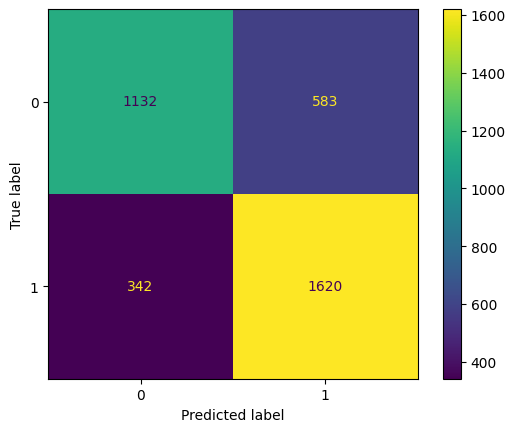

In [149]:
# Display confusion matrix.
ConfusionMatrixDisplay(confusion_matrix(y_train,insample_predictions)).plot()

### Out-Sample Evaluation

<p align="justify">When evaluating a machine learning model, it is crucial to assess its ability to generalize accurately. This is because models often tend to overfit the data they are trained on. To estimate the model's out-of-sample performance, we will now make predictions on the test data.</p>

In [150]:
# Make predictions and evaluate performance
outsample_predictions=pipeline.predict(X_test)
print(classification_report(y_test,outsample_predictions))

              precision    recall  f1-score   support

           0       0.65      0.57      0.61       735
           1       0.66      0.74      0.70       841

    accuracy                           0.66      1576
   macro avg       0.66      0.65      0.65      1576
weighted avg       0.66      0.66      0.65      1576



### Confusion matrix of test data

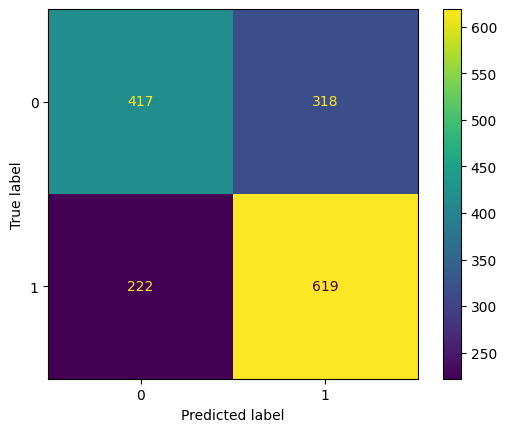

In [151]:
# Display confusion matrix.
ConfusionMatrixDisplay(confusion_matrix(y_test,outsample_predictions)).plot()

## Model Validation on a New Location

<p align="justify">Once you are satisfied with your model, you can validate the model on the dataset of a different location. To do this, use your model to predict the frog occurrence status for a set of test coordinates provided in the <b>"Test.csv"</b> file and share the predicted results to the instructor/professor.</p>

In [152]:
#Reading the coordinates for the validation dataset
test_file = pd.read_csv('../data/Test.csv')
test_file.head()

,ID,Latitude,Longitude
0,ID_TS_54240C,-33.121788,150.320746
1,ID_TS_EF9635,-36.592011,148.172262
2,ID_TS_4E63E6,-35.455100,146.693465
3,ID_TS_FDAB8E,-33.076261,149.547177
4,ID_TS_E00D49,-35.529729,146.627272


In [153]:
# check dataframe shape
test_file.shape

(2000, 3)

In [154]:
# Mapping satellite data with test data.
final_val_data = map_satellite_data('TerraClimate_output.tiff', '../data/Test.csv')

Extracting raster values: 100%|██████████| 2000/2000 [00:01<00:00, 1108.33it/s]


In [155]:
# Display first 5 rows
final_val_data.head()

,srad,vap
0,205.69839477539062,1.0170000791549683
1,197.801513671875,0.8270000219345093
2,221.59686279296875,0.9630000591278076
3,219.70147705078125,0.9620000720024109
4,221.70089721679688,0.9640000462532043


In [161]:
# Loading the trained model and predict on validation data.
# loaded_pipeline = joblib.load("regression_pipeline.pkl")
# final_predictions = loaded_pipeline.predict(final_val_data)
final_predictions = pipeline.predict(final_val_data)
final_prediction_series = pd.Series(final_predictions)

In [162]:
#Combining the results into dataframe
submission_df = pd.DataFrame({'ID': test_file['ID'].values, 'Latitude':test_file['Latitude'].values, 'Longitude':test_file['Longitude'].values,  'Occurrence Status':final_prediction_series.values})

In [163]:
#Displaying the dataframe
display(submission_df)

,ID,Latitude,Longitude,Occurrence Status
0,ID_TS_54240C,-33.121788,150.320746,1
1,ID_TS_EF9635,-36.592011,148.172262,0
2,ID_TS_4E63E6,-35.455100,146.693465,0
3,ID_TS_FDAB8E,-33.076261,149.547177,1
4,ID_TS_E00D49,-35.529729,146.627272,0
...,...,...,...,...
1995,ID_TS_EF86CB,-33.342761,145.736478,0
1996,ID_TS_AFE511,-34.455690,150.442003,1
1997,ID_TS_B65EDA,-36.241444,144.720379,0
1998,ID_TS_731F26,-32.194000,148.900320,1


## Zindi Submission

In order to submit your predictions on Zindi, you only need to keep the `ID` and `Occurrence Status`. I will also rename the `Occurrence Status` to `Target`

In [164]:
submission_zindi_df = submission_df[['ID','Occurrence Status']]
submission_zindi_df.rename(columns={'Occurrence Status':'Target'},inplace=True)

submission_zindi_df.head()

,ID,Target
0,ID_TS_54240C,1
1,ID_TS_EF9635,0
2,ID_TS_4E63E6,0
3,ID_TS_FDAB8E,1
4,ID_TS_E00D49,0


In [165]:
#Dumping the predictions into a csv file.
#You can use a different name for your file if you want. As long as it is a csv file
#index=False is compulsory
submission_zindi_df.to_csv("../submissions/rf-no-tuning.csv",index = False)

## Conclusion

Now that you have learned a basic approach to model training, it’s time to try your own approach! Feel free to modify any of the functions presented in this notebook. Once you build the final model, please share Predicted_Dataset.csv file with instructor/professor for them to evaluate the performance of the model. Best of luck and heppy learning!

In [35]:
import pandas as pd
import optuna

import sys
sys.path.append("../scripts")

from tuner import ClassificationTuner
from sklearn.feature_selection import SequentialFeatureSelector, RFE
from sklearn.model_selection import train_test_split, permutation_test_score, StratifiedKFold
from sklearn.inspection import permutation_importance

In [12]:
test = pd.read_csv("../data/test-with-satellite-features.csv")

In [13]:
study = optuna.load_study(study_name="classification_tuning", storage="sqlite:///../tuning/classification_tuning.db")

In [14]:
study.best_value

0.8205264830063852

In [15]:
X = test.drop(["latitude", "longitude"], axis=1)

In [16]:
pipeline = ClassificationTuner._build_from_params(study.best_params, n_features=X.shape[1])

In [17]:
model = ClassificationTuner._model_from_params(study.best_params)[1]

In [18]:
train = pd.read_csv("../data/training-with-satellite-features.csv").dropna(
    axis=0
)  ## TODO: make sure to make this part of the pipeline (imputation)
X_all = train.drop(["latitude", "longitude", "Occurrence Status"], axis=1).values
y_all = train["Occurrence Status"].values

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.3, random_state=42)

In [22]:
rfe = RFE(model, n_features_to_select=X.shape[1])
rfe.fit(X_train, y_train)

RFE(estimator=RandomForestClassifier(max_depth=10,
                                     max_features=0.5783348366585687,
                                     min_samples_split=9, n_estimators=377,
                                     n_jobs=-1, random_state=42),
    n_features_to_select=14)

In [29]:
model.fit(X_train, y_train).score(X_train, y_train)

0.865323675871435

In [30]:
importances = permutation_importance(rfe, X_test, y_test, n_repeats=10, random_state=42)

In [31]:
importances.importances_mean

array([0.01055966, 0.00786695, 0.056283  , 0.00332629, 0.0093981 ,
       0.00153115, 0.01145723, 0.03505808, 0.        , 0.00554382,
       0.006283  , 0.01610348, 0.00295671, 0.00860612])

In [33]:
pval = permutation_test_score(rfe, X_test, y_test, scoring="f1", random_state=42, n_jobs=-1)

In [34]:
pval

(np.float64(0.8042655886088209),
 array([0.69604037, 0.69652242, 0.68103352, 0.68939777, 0.69334893,
        0.69385976, 0.6816213 , 0.68968011, 0.70673774, 0.68492602,
        0.69421141, 0.68034471, 0.69495126, 0.69685419, 0.68384911,
        0.67944963, 0.67881551, 0.69292093, 0.68788559, 0.68320632,
        0.69212505, 0.68521382, 0.69398786, 0.68736392, 0.68937223,
        0.68771736, 0.6715711 , 0.68043389, 0.69996279, 0.6929784 ,
        0.69622305, 0.68866409, 0.68420541, 0.69009409, 0.6855548 ,
        0.67985909, 0.68145467, 0.69417859, 0.67862482, 0.67764558,
        0.69116854, 0.68504694, 0.68958292, 0.67111028, 0.6900849 ,
        0.67345643, 0.68747954, 0.69462082, 0.68618264, 0.69499733,
        0.68153854, 0.69299706, 0.69180498, 0.67352356, 0.67748065,
        0.6811544 , 0.70376284, 0.68978433, 0.6921178 , 0.70141847,
        0.68036011, 0.69779389, 0.68048466, 0.69355455, 0.69721338,
        0.68711489, 0.68348718, 0.6907468 , 0.68747273, 0.67442187,
        0.67987

In [23]:
rfe.ranking_

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [36]:
sqs = SequentialFeatureSelector(
    model,
    n_features_to_select=4,
    direction="forward",
    scoring="f1",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1,
)

sqs.fit(X_train, y_train)

SequentialFeatureSelector(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
                          estimator=RandomForestClassifier(max_depth=10,
                                                           max_features=0.5783348366585687,
                                                           min_samples_split=9,
                                                           n_estimators=377,
                                                           n_jobs=-1,
                                                           random_state=42),
                          n_features_to_select=4, n_jobs=-1, scoring='f1')

In [39]:
sqs.get_support()

array([False, False, False, False, False,  True,  True,  True, False,
        True, False, False, False, False])

In [46]:
train.drop(["latitude", "longitude", "Occurrence Status"], axis=1).columns

Index(['aet', 'def', 'pdsi', 'pet', 'ppt', 'q', 'soil', 'srad', 'swe', 'tmax',
       'tmin', 'vap', 'vpd', 'ws'],
      dtype='object')

In [ ]:
X_sqs_train = sqs.transform(X_train)

model.fit(X_sqs_train, y_train)

RandomForestClassifier(max_depth=10, max_features=0.5783348366585687,
                       min_samples_split=9, n_estimators=377, n_jobs=-1,
                       random_state=42)

In [42]:
from sklearn.metrics import f1_score
X_sqs_test = sqs.transform(X_test)
f1_score(y_test, model.predict(X_sqs_test))

np.float64(0.8109881098810988)

In [18]:
model.fit(X_all, y_all)

RandomForestClassifier(max_depth=10, max_features=0.5783348366585687,
                       min_samples_split=9, n_estimators=377, n_jobs=-1,
                       random_state=42)

In [19]:
predictions = model.predict(X.values)

In [21]:
ids = pd.read_csv("../data/Test.csv")["ID"]

In [22]:
sub = pd.concat(
    [
        pd.DataFrame(ids, columns=["ID"]),
        pd.DataFrame(predictions, columns=["Occurrence Status"]),
    ],
    axis=1,
)
sub.to_csv("submission.csv", index=False)